# HOTEL RESERVATION CANECELLATION PREDICTOR

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

# PREPROCESSING ( ANALYZING + EDA )

In [2]:
df = pd.read_csv( "hotel_bookings.csv")

In [3]:
df.shape

(119390, 32)

In [4]:
print( df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')


In [5]:
cols = df.columns

In [6]:

for index , feature in enumerate(cols) :
    print( index , " " , feature , " " ,df[feature].isnull().sum())

0   hotel   0
1   is_canceled   0
2   lead_time   0
3   arrival_date_year   0
4   arrival_date_month   0
5   arrival_date_week_number   0
6   arrival_date_day_of_month   0
7   stays_in_weekend_nights   0
8   stays_in_week_nights   0
9   adults   0
10   children   4
11   babies   0
12   meal   0
13   country   488
14   market_segment   0
15   distribution_channel   0
16   is_repeated_guest   0
17   previous_cancellations   0
18   previous_bookings_not_canceled   0
19   reserved_room_type   0
20   assigned_room_type   0
21   booking_changes   0
22   deposit_type   0
23   agent   16340
24   company   112593
25   days_in_waiting_list   0
26   customer_type   0
27   adr   0
28   required_car_parking_spaces   0
29   total_of_special_requests   0
30   reservation_status   0
31   reservation_status_date   0


In [7]:

for index , feature in enumerate(cols) :
    print( index , " " , feature , " " ,df[feature].unique())

0   hotel   <ArrowStringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
1   is_canceled   [0 1]
2   lead_time   [342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200 192


In [8]:
df['agent'].value_counts()

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
         ...  
444.0        1
408.0        1
388.0        1
453.0        1
480.0        1
Name: count, Length: 333, dtype: int64

In [9]:
top_20_agents = df['agent'].value_counts().head(30)

In [10]:
top_20_agents

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
8.0       1514
3.0       1336
37.0      1230
19.0      1061
40.0      1039
314.0      927
21.0       875
229.0      786
242.0      780
83.0       696
29.0       683
171.0      607
12.0       578
85.0       554
20.0       540
96.0       537
243.0      514
30.0       484
134.0      482
298.0      472
27.0       450
Name: count, dtype: int64

In [11]:
df.groupby('agent')['is_canceled'].mean().head(30)

agent
1.0     0.734251
2.0     0.209877
3.0     0.577096
4.0     0.659574
5.0     0.451515
6.0     0.311550
7.0     0.133936
8.0     0.282034
9.0     0.415006
10.0    0.246154
11.0    0.265823
12.0    0.525952
13.0    0.304878
14.0    0.179121
15.0    0.300995
16.0    0.077236
17.0    0.477178
19.0    0.735156
20.0    0.664815
21.0    0.578286
22.0    0.117801
23.0    0.080000
24.0    0.000000
25.0    0.000000
26.0    0.326683
27.0    0.100000
28.0    0.066026
29.0    0.799414
30.0    0.390496
31.0    0.950617
Name: is_canceled, dtype: float64

In [12]:
agent_analysis = (
    df.groupby('agent')['is_canceled']
      .agg(['count', 'mean'])
      .sort_values('count', ascending=False)
)

agent_analysis.columns = ['booking_count', 'cancellation_rate']

print(agent_analysis.head(30))

       booking_count  cancellation_rate
agent                                  
9.0            31961           0.415006
240.0          13922           0.393909
1.0             7191           0.734251
14.0            3640           0.179121
7.0             3539           0.133936
6.0             3290           0.311550
250.0           2870           0.178746
241.0           1721           0.137130
28.0            1666           0.066026
8.0             1514           0.282034
3.0             1336           0.577096
37.0            1230           0.582927
19.0            1061           0.735156
40.0            1039           0.080847
314.0            927           0.175836
21.0             875           0.578286
229.0            786           0.615776
242.0            780           0.333333
83.0             696           0.271552
29.0             683           0.799414
171.0            607           0.283361
12.0             578           0.525952
85.0             554           0.198556


In [13]:
df['company'].value_counts().head(20)

company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
174.0    149
219.0    141
281.0    138
154.0    133
405.0    119
233.0    114
51.0      99
94.0      87
47.0      72
135.0     66
169.0     65
242.0     62
331.0     61
348.0     59
498.0     58
Name: count, dtype: int64

In [14]:
df['country'].value_counts().head(20)

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
USA     2097
CHE     1730
CN      1279
AUT     1263
SWE     1024
CHN      999
POL      919
ISR      669
RUS      632
NOR      607
Name: count, dtype: int64

In [15]:
lst = df.groupby('country')['is_canceled'].mean() * 100 


In [16]:
print(lst.head(20))

country
ABW      0.000000
AGO     56.629834
AIA      0.000000
ALB     16.666667
AND     71.428571
ARE     84.313725
ARG     25.233645
ARM     25.000000
ASM      0.000000
ATA      0.000000
ATF      0.000000
AUS     25.117371
AUT     18.210610
AZE     52.941176
BDI      0.000000
BEL     20.239112
BEN    100.000000
BFA      0.000000
BGD     75.000000
BGR     16.000000
Name: is_canceled, dtype: float64


In [17]:

country_counts = df['country'].value_counts()

top_20_percentage = (
    country_counts.head(20).sum() / len(df)
) * 100

print(top_20_percentage)

93.8261160901248


In [18]:
country_analysis = (
    df.groupby('country')['is_canceled']
      .agg(['count', 'mean'])
      .sort_values('count', ascending=False)
)

country_analysis.columns = ['booking_count', 'cancellation_rate']

print(country_analysis.head(20))

         booking_count  cancellation_rate
country                                  
PRT              48590           0.566351
GBR              12129           0.202243
FRA              10415           0.185694
ESP               8568           0.254085
DEU               7287           0.167147
ITA               3766           0.353956
IRL               3375           0.246519
BEL               2342           0.202391
BRA               2224           0.373201
NLD               2104           0.183935
USA               2097           0.238913
CHE               1730           0.247399
CN                1279           0.198593
AUT               1263           0.182106
SWE               1024           0.221680
CHN                999           0.462462
POL                919           0.233950
ISR                669           0.252616
RUS                632           0.378165
NOR                607           0.298188


In [19]:
df = df.drop(columns=['reservation_status_date'])

In [20]:
df = df.drop(columns=['reservation_status'])

In [21]:
df['meal'] = df['meal'].replace('Undefined', 'SC')

In [22]:
df = df.drop(columns=['company'])

In [23]:
df['adults'].value_counts().sort_index()

adults
0       403
1     23027
2     89680
3      6202
4        62
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

In [24]:
df[['adults', 'children', 'babies']].describe()

,adults,children,babies
count,119390.000000,119386.000000,119390.000000
mean,1.856403,0.103890,0.007949
std,0.579261,0.398561,0.097436
min,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,2.000000,0.000000,0.000000
max,55.000000,10.000000,10.000000


In [25]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [26]:
df['adr'].sort_values(ascending=False).head(20)

48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
13391      437.00
39155      426.25
39568      402.00
39118      397.38
13323      392.00
39517      392.00
39543      388.00
13406      388.00
39177      387.00
9728       384.00
39960      383.00
9768       382.00
39644      382.00
38995      378.00
13480      378.00
Name: adr, dtype: float64

In [27]:
df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,A,H,2,No Deposit,273.0,0,Transient-Party,-6.38,0,0


In [28]:
df[df['adr'] > 500]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
15083,Resort Hotel,0,1,2015,July,29,15,0,1,2,...,A,C,0,No Deposit,NaN,0,Transient,508.0,1,0
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,A,A,1,Non Refund,12.0,0,Transient,5400.0,0,0
111403,City Hotel,0,0,2017,May,19,9,0,1,1,...,A,G,0,No Deposit,159.0,0,Transient,510.0,0,0


In [29]:
df[df['adr'] == 5400]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,A,A,1,Non Refund,12.0,0,Transient,5400.0,0,0


In [30]:
df = df[df['adr'] >= 0]

In [31]:
df = df[df['adr'] != 5400]

In [32]:
df['adr'].describe()

count    119388.000000
mean        101.787650
std          48.152738
min           0.000000
25%          69.290000
50%          94.575000
75%         126.000000
max         510.000000
Name: adr, dtype: float64

In [33]:
df[df['children'].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,B,B,0,No Deposit,NaN,0,Transient-Party,12.0,0,1
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,B,B,0,No Deposit,14.0,0,Transient-Party,12.0,0,1
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,B,B,0,No Deposit,NaN,0,Transient-Party,18.0,0,2
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,B,B,0,No Deposit,9.0,0,Transient-Party,76.5,0,1


In [34]:
df['children'] = df['children'].fillna(0)

In [35]:
df[df['babies'] > 2]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
46619,City Hotel,0,37,2016,January,3,12,0,2,2,...,D,D,1,No Deposit,9.0,0,Transient,84.45,0,1
78656,City Hotel,0,11,2015,October,42,11,2,1,1,...,A,B,1,No Deposit,95.0,0,Transient-Party,95.00,0,0


In [36]:
df[df['adults'] > 10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
1539,Resort Hotel,1,304,2015,September,36,3,0,3,40,...,A,A,0,No Deposit,NaN,0,Group,0.0,0,0
1587,Resort Hotel,1,333,2015,September,36,5,2,5,26,...,A,A,0,No Deposit,96.0,0,Group,0.0,0,0
1643,Resort Hotel,1,336,2015,September,37,7,1,2,50,...,A,A,0,No Deposit,NaN,0,Group,0.0,0,0
1752,Resort Hotel,1,340,2015,September,37,12,2,5,26,...,A,A,0,No Deposit,96.0,0,Group,0.0,0,0
1884,Resort Hotel,1,347,2015,September,38,19,2,5,26,...,A,A,0,No Deposit,96.0,0,Group,0.0,0,0
1917,Resort Hotel,1,349,2015,September,39,21,1,3,27,...,A,A,0,No Deposit,NaN,0,Group,0.0,0,0
1962,Resort Hotel,1,352,2015,September,39,24,1,3,27,...,A,A,0,No Deposit,NaN,0,Group,0.0,0,0
2003,Resort Hotel,1,354,2015,September,39,26,2,5,26,...,A,A,0,No Deposit,96.0,0,Group,0.0,0,0
2164,Resort Hotel,1,361,2015,October,40,3,2,5,26,...,A,A,0,No Deposit,96.0,0,Group,0.0,0,0
2173,Resort Hotel,1,338,2015,October,41,4,2,0,55,...,A,A,0,No Deposit,NaN,0,Group,0.0,0,0


In [37]:
df[df['adults'] == 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,A,I,1,No Deposit,NaN,0,Transient-Party,0.00,0,0
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,A,I,0,No Deposit,NaN,0,Transient,0.00,0,0
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,A,C,0,No Deposit,38.0,0,Transient-Party,0.00,0,0
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,A,A,1,No Deposit,308.0,122,Transient-Party,0.00,0,0
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,A,C,1,No Deposit,308.0,122,Transient-Party,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117204,City Hotel,0,296,2017,July,30,27,1,3,0,...,B,A,0,No Deposit,9.0,0,Transient,98.85,0,1
117274,City Hotel,0,276,2017,July,31,30,2,1,0,...,B,B,1,No Deposit,9.0,0,Transient,93.64,0,2
117303,City Hotel,0,291,2017,July,30,29,2,2,0,...,B,A,0,No Deposit,9.0,0,Transient,98.85,0,1
117453,City Hotel,0,159,2017,July,31,31,1,3,0,...,A,A,1,No Deposit,9.0,0,Transient,121.88,0,1


In [38]:
df[df['babies'] > 2][
    ['adults', 'children', 'babies', 'is_canceled',
     'adr', 'stays_in_weekend_nights', 'stays_in_week_nights']
]

,adults,children,babies,is_canceled,adr,stays_in_weekend_nights,stays_in_week_nights
46619,2,0.0,10,0,84.45,0,2
78656,1,0.0,9,0,95.00,2,1


In [39]:
df = df[df['babies'] <= 2]

In [40]:
df[df['adults'] > 10][
    ['adults', 'children', 'babies',
     'is_canceled', 'adr',
     'stays_in_weekend_nights',
     'stays_in_week_nights']
]

,adults,children,babies,is_canceled,adr,stays_in_weekend_nights,stays_in_week_nights
1539,40,0.0,0,1,0.0,0,3
1587,26,0.0,0,1,0.0,2,5
1643,50,0.0,0,1,0.0,1,2
1752,26,0.0,0,1,0.0,2,5
1884,26,0.0,0,1,0.0,2,5
1917,27,0.0,0,1,0.0,1,3
1962,27,0.0,0,1,0.0,1,3
2003,26,0.0,0,1,0.0,2,5
2164,26,0.0,0,1,0.0,2,5
2173,55,0.0,0,1,0.0,2,0


In [41]:
df = df[df['adults'] <= 10]

In [42]:
df[
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
].shape

(180, 29)

In [43]:
df = df[
    ~(
        (df['adults'] == 0) &
        (df['children'] == 0) &
        (df['babies'] == 0)
    )
]# un cases ko hatta do jisme sb zero ho

In [44]:
df['lead_time'].describe()

count    119194.000000
mean        104.086674
std         106.855359
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

In [45]:
df['lead_time'].sort_values(ascending=False).head(20)

1        737
4182     709
65251    629
65250    629
65242    629
65244    629
65253    629
65252    629
65254    629
65249    629
65245    629
65243    629
65235    629
65241    629
65238    629
65231    629
65237    629
65239    629
65240    629
60373    626
Name: lead_time, dtype: int64

In [46]:
df.groupby('is_canceled')['lead_time'].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75008.0,80.081991,91.138169,0.0,9.00,45.0,124.0,737.0
1,44186.0,144.835853,118.584409,0.0,48.25,113.0,214.0,629.0


In [47]:
df[['stays_in_weekend_nights',
   'stays_in_week_nights']].describe()

,stays_in_weekend_nights,stays_in_week_nights
count,119194.000000,119194.000000
mean,0.926968,2.499060
std,0.995089,1.897083
min,0.000000,0.000000
25%,0.000000,1.000000
50%,1.000000,2.000000
75%,2.000000,3.000000
max,19.000000,50.000000


In [48]:
df['stays_in_weekend_nights'].value_counts().sort_index()

stays_in_weekend_nights
0     51892
1     30612
2     33257
3      1252
4      1846
5        77
6       152
7        19
8        58
9        10
10        7
12        5
13        2
14        1
16        2
18        1
19        1
Name: count, dtype: int64

In [49]:
df['stays_in_week_nights'].value_counts().sort_index()

stays_in_week_nights
0      7571
1     30290
2     33668
3     22238
4      9543
5     11061
6      1493
7      1024
8       654
9       228
10     1030
11       55
12       42
13       27
14       35
15       85
16       15
17        4
18        6
19       43
20       39
21       15
22        7
24        3
25        6
26        1
30        4
32        1
33        1
34        1
40        2
42        1
50        1
Name: count, dtype: int64

In [50]:
df['total_stay_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

In [51]:
df['total_stay_nights'].sort_values(ascending=False).head(20)

14038     69
14037     60
9839      56
33924     56
54704     48
1655      46
32589     45
3820      42
34898     42
34614     42
3850      42
35059     38
32946     35
33620     35
33234     35
31404     35
20835     35
103282    34
5344      33
80972     33
Name: total_stay_nights, dtype: int64

In [52]:
df['total_stay_nights'].describe()

count    119194.000000
mean          3.426028
std           2.540625
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          69.000000
Name: total_stay_nights, dtype: float64

In [53]:
total_stay_nights = df['total_stay_nights']

In [54]:
df.drop( ['total_stay_nights'] , axis = 1 , inplace = True)

In [55]:
df['booking_changes'].describe()

count    119194.000000
mean          0.218778
std           0.638507
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          18.000000
Name: booking_changes, dtype: float64

In [56]:
df['booking_changes'].value_counts().sort_index()

booking_changes
0     101221
1      12662
2       3779
3        914
4        367
5        115
6         61
7         29
8         14
9          8
10         6
11         1
12         1
13         5
14         3
15         3
16         2
17         2
18         1
Name: count, dtype: int64

In [57]:
df['booking_changes'].describe()

count    119194.000000
mean          0.218778
std           0.638507
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          18.000000
Name: booking_changes, dtype: float64

In [58]:
df['days_in_waiting_list'].value_counts().sort_index()

days_in_waiting_list
0      115501
1          12
2           5
3          59
4          25
        ...  
236        35
259        10
330        15
379        15
391        45
Name: count, Length: 127, dtype: int64

In [59]:
df['days_in_waiting_list'].describe()

count    119194.000000
mean          2.321526
std          17.599162
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         391.000000
Name: days_in_waiting_list, dtype: float64

In [60]:
df['required_car_parking_spaces'].value_counts().sort_index()

required_car_parking_spaces
0    111785
1      7376
2        28
3         3
8         2
Name: count, dtype: int64

In [61]:
df['required_car_parking_spaces'].describe()

count    119194.000000
mean          0.062562
std           0.245375
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: required_car_parking_spaces, dtype: float64

In [62]:
df['total_of_special_requests'].describe()

count    119194.000000
mean          0.571572
std           0.792902
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           5.000000
Name: total_of_special_requests, dtype: float64

In [63]:
df['total_of_special_requests'].value_counts().sort_index()

total_of_special_requests
0    70186
1    33182
2    12952
3     2494
4      340
5       40
Name: count, dtype: int64

In [64]:
df['meal'].value_counts()

meal
BB    92223
HB    14455
SC    11718
FB      798
Name: count, dtype: int64

In [65]:
df['country'].isna().sum()

np.int64(478)

In [66]:
df['country'] = df['country'].fillna('Unknown')

In [67]:
df['market_segment'].value_counts()

market_segment
Online TA        56407
Offline TA/TO    24176
Groups           19790
Direct           12575
Corporate         5281
Complementary      728
Aviation           235
Undefined            2
Name: count, dtype: int64

In [68]:
df[df['market_segment'] == 'Undefined']

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,B,B,0,No Deposit,NaN,0,Transient-Party,12.0,0,1
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,B,B,0,No Deposit,NaN,0,Transient-Party,18.0,0,2


In [69]:
df['distribution_channel'].value_counts()


distribution_channel
TA/TO        97743
Direct       14603
Corporate     6650
GDS            193
Undefined        5
Name: count, dtype: int64

In [70]:
df[df['distribution_channel'] == 'Undefined']


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
14594,Resort Hotel,0,103,2015,July,28,5,2,3,2,...,A,A,0,No Deposit,NaN,0,Transient,112.7,1,2
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,B,B,0,No Deposit,NaN,0,Transient-Party,12.0,0,1
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,B,B,0,No Deposit,14.0,0,Transient-Party,12.0,0,1
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,B,B,0,No Deposit,NaN,0,Transient-Party,18.0,0,2
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,B,B,0,No Deposit,9.0,0,Transient-Party,76.5,0,1


In [71]:
df['deposit_type'].value_counts()

deposit_type
No Deposit    104446
Non Refund     14586
Refundable       162
Name: count, dtype: int64

In [72]:
df['customer_type'].value_counts()


customer_type
Transient          89474
Transient-Party    25086
Contract            4072
Group                562
Name: count, dtype: int64

In [73]:
df['reserved_room_type'].value_counts()

reserved_room_type
A    85860
D    19176
E     6519
F     2894
G     2092
B     1115
C      931
H      601
L        6
Name: count, dtype: int64

In [74]:
df['assigned_room_type'].value_counts()

assigned_room_type
A    74009
D    25306
E     7798
F     3751
G     2549
C     2370
B     2153
H      711
I      359
K      187
L        1
Name: count, dtype: int64

In [75]:
df['is_repeated_guest'].value_counts()

is_repeated_guest
0    115440
1      3754
Name: count, dtype: int64

In [76]:
df.groupby('is_repeated_guest')['is_canceled'].mean()*100

is_repeated_guest
0    37.799723
1    14.651039
Name: is_canceled, dtype: float64

In [77]:
df['previous_cancellations'].value_counts().sort_index()


previous_cancellations
0     112715
1       6048
2        114
3         65
4         31
5         19
6         22
11        35
13        12
14        14
19        19
21         1
24        48
25        25
26        26
Name: count, dtype: int64

In [78]:
df['previous_bookings_not_canceled'].value_counts().sort_index()

previous_bookings_not_canceled
0     115582
1       1538
2        579
3        333
4        229
       ...  
68         1
69         1
70         1
71         1
72         1
Name: count, Length: 73, dtype: int64

In [79]:
df['agent'].isna().mean() * 100

np.float64(13.652532845613033)

In [80]:
df['agent'].nunique()

333

In [81]:
df['agent'].value_counts().head(20)

agent
9.0      31921
240.0    13922
1.0       7187
14.0      3633
7.0       3532
6.0       3290
250.0     2870
241.0     1721
28.0      1657
8.0       1514
3.0       1336
37.0      1228
19.0      1056
40.0      1039
314.0      927
21.0       873
229.0      783
242.0      780
83.0       696
29.0       682
Name: count, dtype: int64

In [82]:
df['agent'] = df['agent'].fillna('absent')

In [83]:
df['agent'].value_counts().head()

agent
9.0       31921
absent    16273
240.0     13922
1.0        7187
14.0       3633
Name: count, dtype: int64

In [84]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')

In [85]:
df['days_in_waiting_list'].value_counts().sort_index()

days_in_waiting_list
0      115501
1          12
2           5
3          59
4          25
        ...  
236        35
259        10
330        15
379        15
391        45
Name: count, Length: 127, dtype: int64

In [86]:
df = df.drop(columns=[
    'arrival_date_year',
    'arrival_date_week_number',
    
])

In [87]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_month                0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [88]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_month                    str
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                              object
days_in_waiting_list                int64
customer_type                     

In [89]:
df['is_canceled'].value_counts()

is_canceled
0    75008
1    44186
Name: count, dtype: int64

In [90]:
df['is_canceled'].value_counts(normalize=True) * 100


is_canceled
0    62.929342
1    37.070658
Name: proportion, dtype: float64

In [91]:
target = 'is_canceled'
freq_cols = [
    'agent',
    'country'
]
cat_cols = [
    'hotel',
    'arrival_date_month',
    'meal',
    
    'market_segment',
    'distribution_channel',
    'is_repeated_guest',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    
    'customer_type'
]
num_cols = [
    'lead_time',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

In [92]:
X = df.drop(columns='is_canceled')
y = df['is_canceled']

In [93]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [94]:
# Frequency encoding using ONLY training data

agent_freq = X_train['agent'].value_counts()

country_freq = X_train['country'].value_counts()

In [95]:
X_train['agent'] = X_train['agent'].map(agent_freq).fillna(0)
X_test['agent'] = X_test['agent'].map(agent_freq).fillna(0)

X_train['country'] = X_train['country'].map(country_freq).fillna(0)
X_test['country'] = X_test['country'].map(country_freq).fillna(0)

In [96]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [97]:
encoder.fit(X_train[cat_cols])

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [98]:
X_train_encoded = encoder.transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

In [99]:
X_train_encoded.shape

(95355, 60)

In [100]:
len(encoder.get_feature_names_out(cat_cols))

60

In [101]:
encoder.get_feature_names_out(cat_cols)

array(['hotel_City Hotel', 'hotel_Resort Hotel',
       'arrival_date_month_April', 'arrival_date_month_August',
       'arrival_date_month_December', 'arrival_date_month_February',
       'arrival_date_month_January', 'arrival_date_month_July',
       'arrival_date_month_June', 'arrival_date_month_March',
       'arrival_date_month_May', 'arrival_date_month_November',
       'arrival_date_month_October', 'arrival_date_month_September',
       'meal_BB', 'meal_FB', 'meal_HB', 'meal_SC',
       'market_segment_Aviation', 'market_segment_Complementary',
       'market_segment_Corporate', 'market_segment_Direct',
       'market_segment_Groups', 'market_segment_Offline TA/TO',
       'market_segment_Online TA', 'market_segment_Undefined',
       'distribution_channel_Corporate', 'distribution_channel_Direct',
       'distribution_channel_GDS', 'distribution_channel_TA/TO',
       'distribution_channel_Undefined', 'is_repeated_guest_0',
       'is_repeated_guest_1', 'reserved_room_type_A',


In [102]:
num_cols = [
    'lead_time',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

In [103]:
X_train_cat = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

In [104]:
X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

In [105]:
X_train_final = pd.concat(
    [
        X_train_num,
        X_train_cat,
        X_train[freq_cols]
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_num,
        X_test_cat,
        X_test[freq_cols]
    ],
    axis=1
)

In [106]:
print(X_train_final.shape)
print(X_test_final.shape)

(95355, 76)
(23839, 76)


In [107]:
print(X_train_final.isnull().sum().sum())
print(X_test_final.isnull().sum().sum())

0
0


In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[num_cols + ['agent', 'country']] = scaler.fit_transform(
    X_train_final[num_cols + ['agent', 'country']]
)

X_test_final[num_cols + ['agent', 'country']] = scaler.transform(
    X_test_final[num_cols + ['agent', 'country']]
)

# Begins the model fitting part 

__Logisitic Regression__


In [109]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [110]:
y_pred = log_reg.predict(X_test_final)

y_prob = log_reg.predict_proba(X_test_final)[:, 1]

In [111]:
print(log_reg.score(X_test_final, y_test))

0.8191618775955367


In [112]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Predictions
y_pred = log_reg.predict(X_test_final)

# Probability of cancellation
y_prob = log_reg.predict_proba(X_test_final)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== Logistic Regression Results =====")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

===== Logistic Regression Results =====
Accuracy  : 0.8192
Precision : 0.8100
Recall    : 0.6691
ROC-AUC   : 0.8957

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     15002
           1       0.81      0.67      0.73      8837

    accuracy                           0.82     23839
   macro avg       0.82      0.79      0.80     23839
weighted avg       0.82      0.82      0.81     23839

Confusion Matrix:
[[13615  1387]
 [ 2924  5913]]


Using the above result as baseline for this model , now will use all the other known models to find the best baseline , then will perform hyperparamter tuning on the best baseline model 

__Random Forest__

In [113]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [114]:
rf.fit(X_train_final, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [115]:
y_pred_rf = rf.predict(X_test_final)

y_prob_rf = rf.predict_proba(X_test_final)[:, 1]

In [116]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("===== Random Forest Results =====")

print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

===== Random Forest Results =====
Accuracy  : 0.8938
Precision : 0.8880
Recall    : 0.8166
ROC-AUC   : 0.9592

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     15002
           1       0.89      0.82      0.85      8837

    accuracy                           0.89     23839
   macro avg       0.89      0.88      0.88     23839
weighted avg       0.89      0.89      0.89     23839

Confusion Matrix:
[[14092   910]
 [ 1621  7216]]


__HistGradientBoosting__

In [117]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    random_state=42
)

In [118]:
hgb_model.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [119]:

y_pred_hgb = hgb_model.predict(X_test_final)

y_prob_hgb = hgb_model.predict_proba(X_test_final)[:, 1]

In [120]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

accuracy_hgb = accuracy_score(y_test, y_pred_hgb)
precision_hgb = precision_score(y_test, y_pred_hgb)
recall_hgb = recall_score(y_test, y_pred_hgb)
roc_auc_hgb = roc_auc_score(y_test, y_prob_hgb)

print("===== HistGradientBoosting Results =====")

print(f"Accuracy  : {accuracy_hgb:.4f}")
print(f"Precision : {precision_hgb:.4f}")
print(f"Recall    : {recall_hgb:.4f}")
print(f"ROC-AUC   : {roc_auc_hgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))

===== HistGradientBoosting Results =====
Accuracy  : 0.8717
Precision : 0.8555
Recall    : 0.7868
ROC-AUC   : 0.9463

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     15002
           1       0.86      0.79      0.82      8837

    accuracy                           0.87     23839
   macro avg       0.87      0.85      0.86     23839
weighted avg       0.87      0.87      0.87     23839

Confusion Matrix:
[[13828  1174]
 [ 1884  6953]]


__XGBoost__

In [121]:
from xgboost import XGBClassifier

In [122]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [123]:
xgb_model.fit(X_train_final, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [124]:
y_pred_xgb = xgb_model.predict(X_test_final)

y_prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

In [125]:


accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("===== XGBoost Results =====")

print(f"Accuracy  : {accuracy_xgb:.4f}")
print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

===== XGBoost Results =====
Accuracy  : 0.8789
Precision : 0.8602
Recall    : 0.8040
ROC-AUC   : 0.9509

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91     15002
           1       0.86      0.80      0.83      8837

    accuracy                           0.88     23839
   macro avg       0.87      0.86      0.87     23839
weighted avg       0.88      0.88      0.88     23839

Confusion Matrix:
[[13847  1155]
 [ 1732  7105]]


__SO closest two models obtained are XGBoost and Random Forest__ <br>
Will perform hyperparameter tuning on both via the randomSearchCV<br>
( havent taken GridSearchCV as taking too much training the random forest )

__For XGBoost__

In [126]:
# from sklearn.model_selection import RandomizedSearchCV

In [127]:
# xgb = XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='logloss',
#     tree_method='hist',
    
#     random_state=42
# )

# xgb_param_dist = {
#     'n_estimators': [100, 200, 300, 400],
#     'max_depth': [3, 5, 7, 9],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'min_child_weight': [1, 3, 5, 7],
#     'gamma': [0, 0.1, 0.3, 0.5],
#     'subsample': [0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
#     'reg_alpha': [0, 0.1, 0.5, 1],
#     'reg_lambda': [1, 2, 5, 10]
# }

In [128]:
# xgb_search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=xgb_param_dist,
#     n_iter=10,
#     cv=5,
#     scoring='roc_auc',
#     random_state=42,
#     n_jobs=1,
#     verbose=2
# )

# # xgb_search.fit(X_train_final, y_train)

# print("Best XGBoost Parameters:")
# print(xgb_search.best_params_)

# print("Best XGBoost CV ROC-AUC:")
# print(xgb_search.best_score_)

In [129]:
# best_xgb = xgb_search.best_estimator_

# y_pred_xgb_tuned = best_xgb.predict(X_test_final)

# y_prob_xgb_tuned = best_xgb.predict_proba(X_test_final)[:, 1]

In [130]:



# print("===== Tuned XGBoost Results =====")

# print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")

# print(f"Precision : {precision_score(y_test, y_pred_xgb_tuned):.4f}")

# print(f"Recall    : {recall_score(y_test, y_pred_xgb_tuned):.4f}")

# print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_xgb_tuned):.4f}")

# print("\nClassification Report:")

# print(classification_report(y_test, y_pred_xgb_tuned))

# print("Confusion Matrix:")

# print(confusion_matrix(y_test, y_pred_xgb_tuned))

In [131]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# rf = RandomForestClassifier(
#     random_state=42,
#     n_jobs=-1
# )

# rf_param_dist = {
#     'n_estimators': [100, 200, 300, 400],
#     'max_depth': [None, 10, 15, 20, 25],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2'],
#     'class_weight': [None, 'balanced']
# }



In [132]:
# rf_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=rf_param_dist,
#     n_iter=10,
#     cv=3,
#     scoring='roc_auc',
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

# rf_search.fit(X_train_final, y_train)

# print("Best RF Parameters:")
# print(rf_search.best_params_)

# print("Best RF CV ROC-AUC:")
# print(rf_search.best_score_)

In [133]:
# best_rf = rf_search.best_estimator_

In [134]:
# y_pred_rf_tuned = best_rf.predict(X_test_final)
# y_prob_rf_tuned = best_rf.predict_proba(X_test_final)[:,1]

In [135]:

# print("===== Tuned Random Forest Results =====")

# print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
# print(f"Precision : {precision_score(y_test, y_pred_rf_tuned):.4f}")
# print(f"Recall    : {recall_score(y_test, y_pred_rf_tuned):.4f}")
# print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")

# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_rf_tuned))

# print("Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred_rf_tuned))

In [ ]:
  # use the Random Forest that gave ROC-AUC = 0.9592

import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

print(feature_importance.head(20))

                          feature  importance
0                       lead_time    0.120312
75                        country    0.112645
67        deposit_type_No Deposit    0.082496
11                            adr    0.075163
68        deposit_type_Non Refund    0.060607
1       arrival_date_day_of_month    0.059970
13      total_of_special_requests    0.055058
74                          agent    0.051745
3            stays_in_week_nights    0.038250
7          previous_cancellations    0.028851
2         stays_in_weekend_nights    0.024976
12    required_car_parking_spaces    0.021729
9                 booking_changes    0.019438
38       market_segment_Online TA    0.016361
72        customer_type_Transient    0.015977
4                          adults    0.012522
56           assigned_room_type_A    0.012174
36          market_segment_Groups    0.011689
73  customer_type_Transient-Party    0.011371
37   market_segment_Offline TA/TO    0.009266


In [ ]:
import shap
import sklearn
import joblib

# X_shap_test = X_test_final.sample(10, random_state=42)
# print("SHAP:", shap.__version__)
# print("sklearn:", sklearn.__version__)
# print("Model:", type(rf))
# print("Trees:", len(rf.estimators_))
# print("Features:", X_shap_test.shape)

SHAP: 0.52.0
sklearn: 1.9.0
Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Trees: 200
Features: (10, 76)


In [143]:


X_shap = X_test_final.sample(1000, random_state=42)

explainer = shap.TreeExplainer(rf)

shap_values = explainer(
    X_shap,
    approximate=True
)

In [145]:
print("X_shap shape:", X_shap.shape)
print("X_shap columns:", X_shap.columns.tolist())

print("SHAP shape:", shap_values.shape)

X_shap shape: (1000, 76)
X_shap columns: ['lead_time', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'hotel_City Hotel', 'hotel_Resort Hotel', 'arrival_date_month_April', 'arrival_date_month_August', 'arrival_date_month_December', 'arrival_date_month_February', 'arrival_date_month_January', 'arrival_date_month_July', 'arrival_date_month_June', 'arrival_date_month_March', 'arrival_date_month_May', 'arrival_date_month_November', 'arrival_date_month_October', 'arrival_date_month_September', 'meal_BB', 'meal_FB', 'meal_HB', 'meal_SC', 'market_segment_Aviation', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Undefined', 'd

In [146]:
shap_values_class1 = shap_values[:, :, 1]

print(shap_values_class1.shape)

(1000, 76)


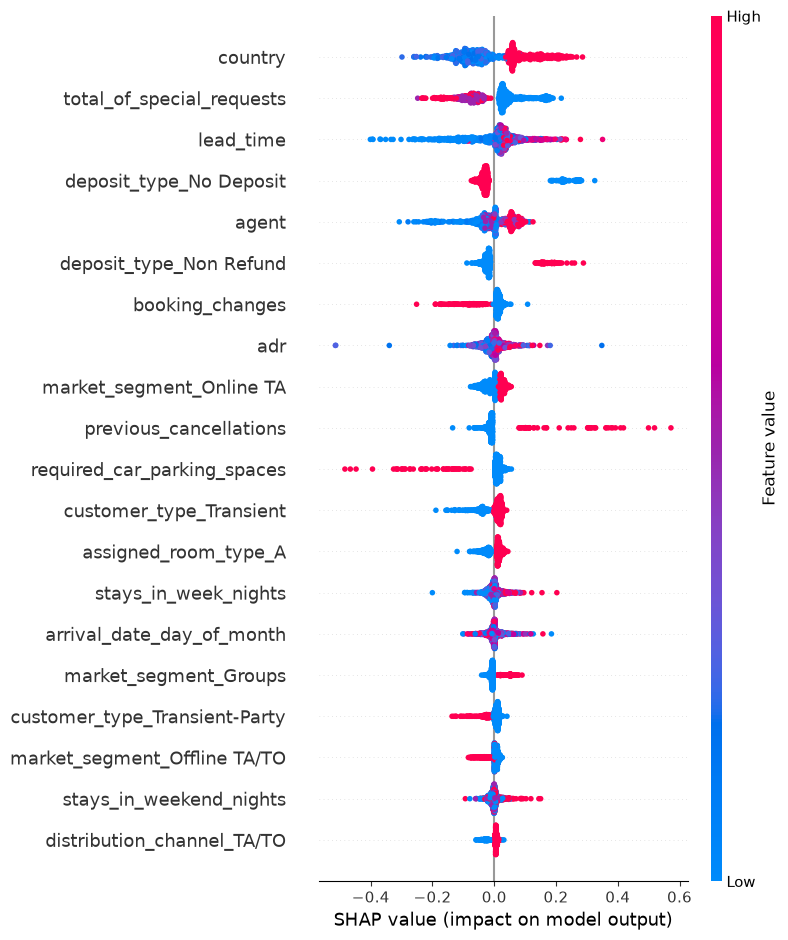

In [147]:
shap.summary_plot(
    shap_values_class1,
    X_shap,
    max_display=20
)

In [148]:
y_prob = rf.predict_proba(X_test_final)[:, 1]

In [149]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

for threshold in thresholds:
    
    y_pred = (y_prob >= threshold).astype(int)
    
    print(f"\nFOR THRESHOLD :- {threshold}")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1        : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")


FOR THRESHOLD :- 0.3
Accuracy  : 0.8705
Precision : 0.7746
Recall    : 0.9177
F1        : 0.8401
ROC-AUC   : 0.9592

FOR THRESHOLD :- 0.35
Accuracy  : 0.8814
Precision : 0.8072
Recall    : 0.8934
F1        : 0.8481
ROC-AUC   : 0.9592

FOR THRESHOLD :- 0.4
Accuracy  : 0.8896
Precision : 0.8378
Recall    : 0.8705
F1        : 0.8539
ROC-AUC   : 0.9592

FOR THRESHOLD :- 0.45
Accuracy  : 0.8935
Precision : 0.8632
Recall    : 0.8469
F1        : 0.8550
ROC-AUC   : 0.9592

FOR THRESHOLD :- 0.5
Accuracy  : 0.8939
Precision : 0.8857
Recall    : 0.8194
F1        : 0.8513
ROC-AUC   : 0.9592

FOR THRESHOLD :- 0.55
Accuracy  : 0.8905
Precision : 0.9034
Recall    : 0.7888
F1        : 0.8423
ROC-AUC   : 0.9592

FOR THRESHOLD :- 0.6
Accuracy  : 0.8843
Precision : 0.9151
Recall    : 0.7583
F1        : 0.8293
ROC-AUC   : 0.9592

FOR THRESHOLD :- 0.65
Accuracy  : 0.8778
Precision : 0.9313
Recall    : 0.7238
F1        : 0.8145
ROC-AUC   : 0.9592

FOR THRESHOLD :- 0.7
Accuracy  : 0.8692
Precision : 0.9476


In [150]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Final threshold
final_threshold = 0.50

# Final predictions
y_pred_final = (y_prob >= final_threshold).astype(int)

print("===== FINAL RANDOM FOREST RESULTS =====")
print(f"Threshold : {final_threshold}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

===== FINAL RANDOM FOREST RESULTS =====
Threshold : 0.5
Accuracy  : 0.8939
Precision : 0.8857
Recall    : 0.8194
F1        : 0.8513
ROC-AUC   : 0.9592

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     15002
           1       0.89      0.82      0.85      8837

    accuracy                           0.89     23839
   macro avg       0.89      0.88      0.88     23839
weighted avg       0.89      0.89      0.89     23839

Confusion Matrix:
[[14068   934]
 [ 1596  7241]]


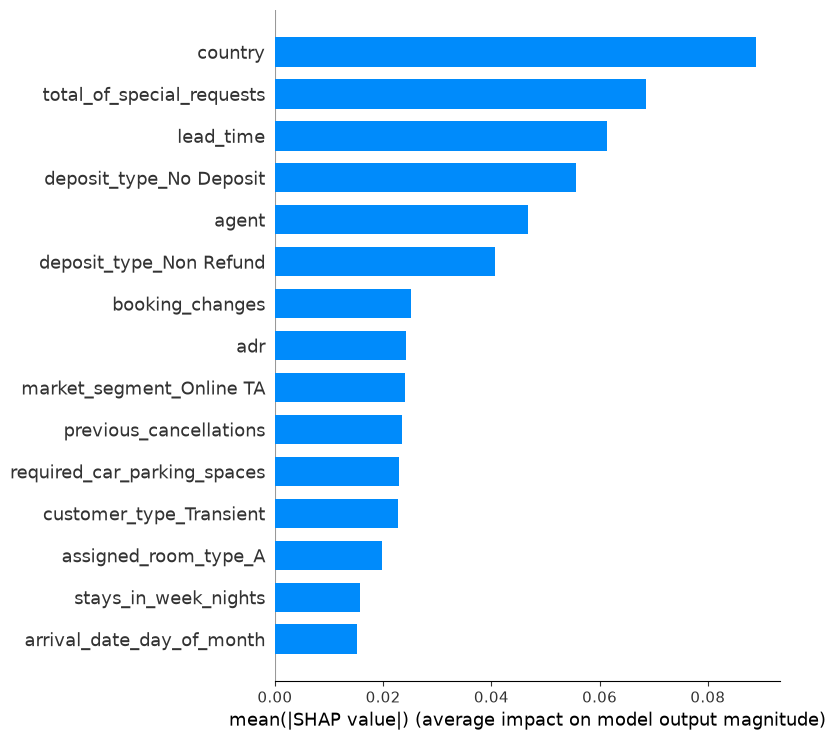

In [152]:
shap.summary_plot(
    shap_values_class1,
    X_shap,
    plot_type="bar",
    max_display=15
)

In [153]:
import joblib

# 1. Final Random Forest
joblib.dump(rf, "random_forest_final.pkl")

# 2. Decision threshold
threshold = 0.5
joblib.dump(threshold, "random_forest_threshold.pkl")

# 3. OneHotEncoder
joblib.dump(encoder, "onehot_encoder.pkl")

# 4. Frequency encoding mappings
joblib.dump(agent_freq, "agent_frequency_map.pkl")
joblib.dump(country_freq, "country_frequency_map.pkl")

# 5. Exact feature order used by the model
feature_columns = X_train_final.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

print("All artifacts saved successfully.")

All artifacts saved successfully.
